### Limpeiza de datos

In [1]:
#Librerias a usar
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Lectura
ruta = "../data/raw/housing.csv"
data = pd.read_csv(ruta) 

In [3]:
# ver las variables categoricas y las numericas
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


None

Se observan las columnas y que la mayoria son numericas y una categorica

In [4]:
#Caracteristicas generales
from IPython.display import display

print(data.shape)
display(data.head())

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Limpieza de datos

In [5]:
#Datos faltantes
valores_faltantes = data.isnull().sum().sort_values(ascending= False)
print("Valores faltantes ordenados: ")
display(valores_faltantes.to_frame('Cantidad de valores faltantes'))

#Elementos duplicados
print(f"\nElementos duplicados: {data.duplicated().sum()}")
#Resumen estadistico 
print("\nResumen estadistico:")
display(data.describe())

Valores faltantes ordenados: 


,Cantidad de valores faltantes
total_bedrooms,207
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0



Elementos duplicados: 0

Resumen estadistico:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


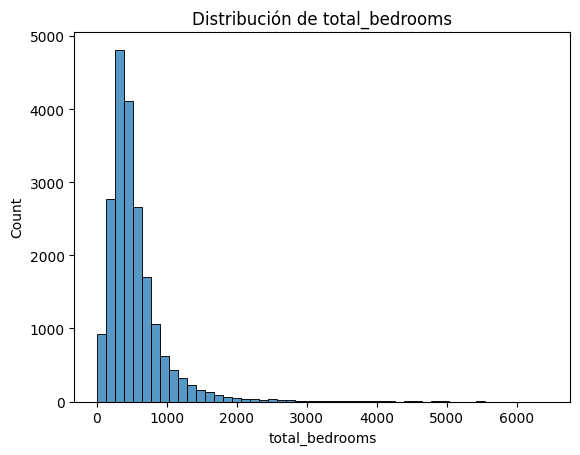

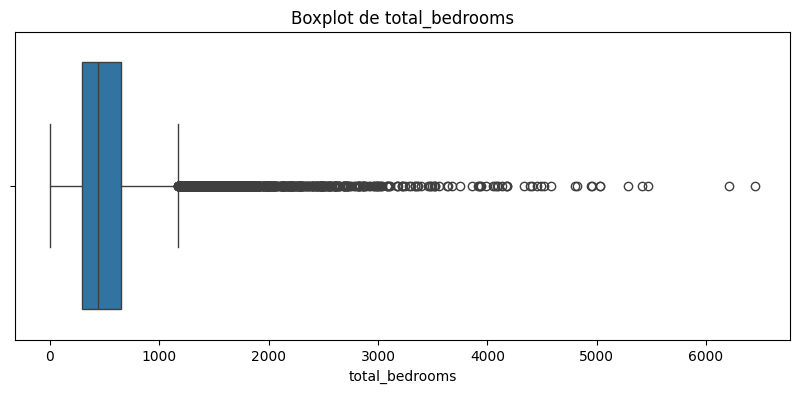

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data['total_bedrooms'], bins=50)
plt.title('Distribución de total_bedrooms')
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=data['total_bedrooms'])
plt.title('Boxplot de total_bedrooms')
plt.show()

In [7]:
print(f"cantidad faltante de bedrooms: {data['total_bedrooms'].isna().sum()}")

#Calculamos la mediana para rellenar datos ya que representa casi al 1% de los datos totales
median_bedrooms = data['total_bedrooms'].median()
print(f'La mediana es {median_bedrooms}')

cantidad faltante de bedrooms: 207
La mediana es 435.0


Se imputaron los valores faltantes de `total_bedrooms` usando la mediana,
debido a la distribución sesgada y presencia de outliers.

In [8]:
#Rellenamos los datos faltantes
print(f'Datos faltantes antes de rellenar : {data['total_bedrooms'].isna().sum()}')
data['total_bedrooms'] = data['total_bedrooms'].fillna(median_bedrooms)
print(f'Datos faltantes despues de rellenar : {data['total_bedrooms'].isna().sum()}')

Datos faltantes antes de rellenar : 207
Datos faltantes despues de rellenar : 0


In [9]:
#Corregimos el tipo de dato de ocean_proximity
data["ocean_proximity"] = data["ocean_proximity"].astype("category")

#Verificamos tipos de datos luego de convertir
print("Tipos de datos post-conversion")
print(data.dtypes)

Tipos de datos post-conversion
longitude              float64
latitude               float64
housing_median_age     float64
total_rooms            float64
total_bedrooms         float64
population             float64
households             float64
median_income          float64
median_house_value     float64
ocean_proximity       category
dtype: object


In [10]:
#Corregimos el tipo de dato de las numericas
int_cols = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households']
data[int_cols].isna().sum() # Corroborar que sea 0 
data[int_cols] = data[int_cols].astype(int)

In [11]:
#Ver si corregimos todo
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  int64   
 3   total_rooms         20640 non-null  int64   
 4   total_bedrooms      20640 non-null  int64   
 5   population          20640 non-null  int64   
 6   households          20640 non-null  int64   
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  float64 
 9   ocean_proximity     20640 non-null  category
dtypes: category(1), float64(4), int64(5)
memory usage: 1.4 MB


Se ajustaron los tipos de datos según su naturaleza:
- Variables de conteo se convirtieron a `int`
- Variables continuas se mantuvieron como `float`
- Variables categóricas se convirtieron a `category`

## Ver los outliers en las variables numericas

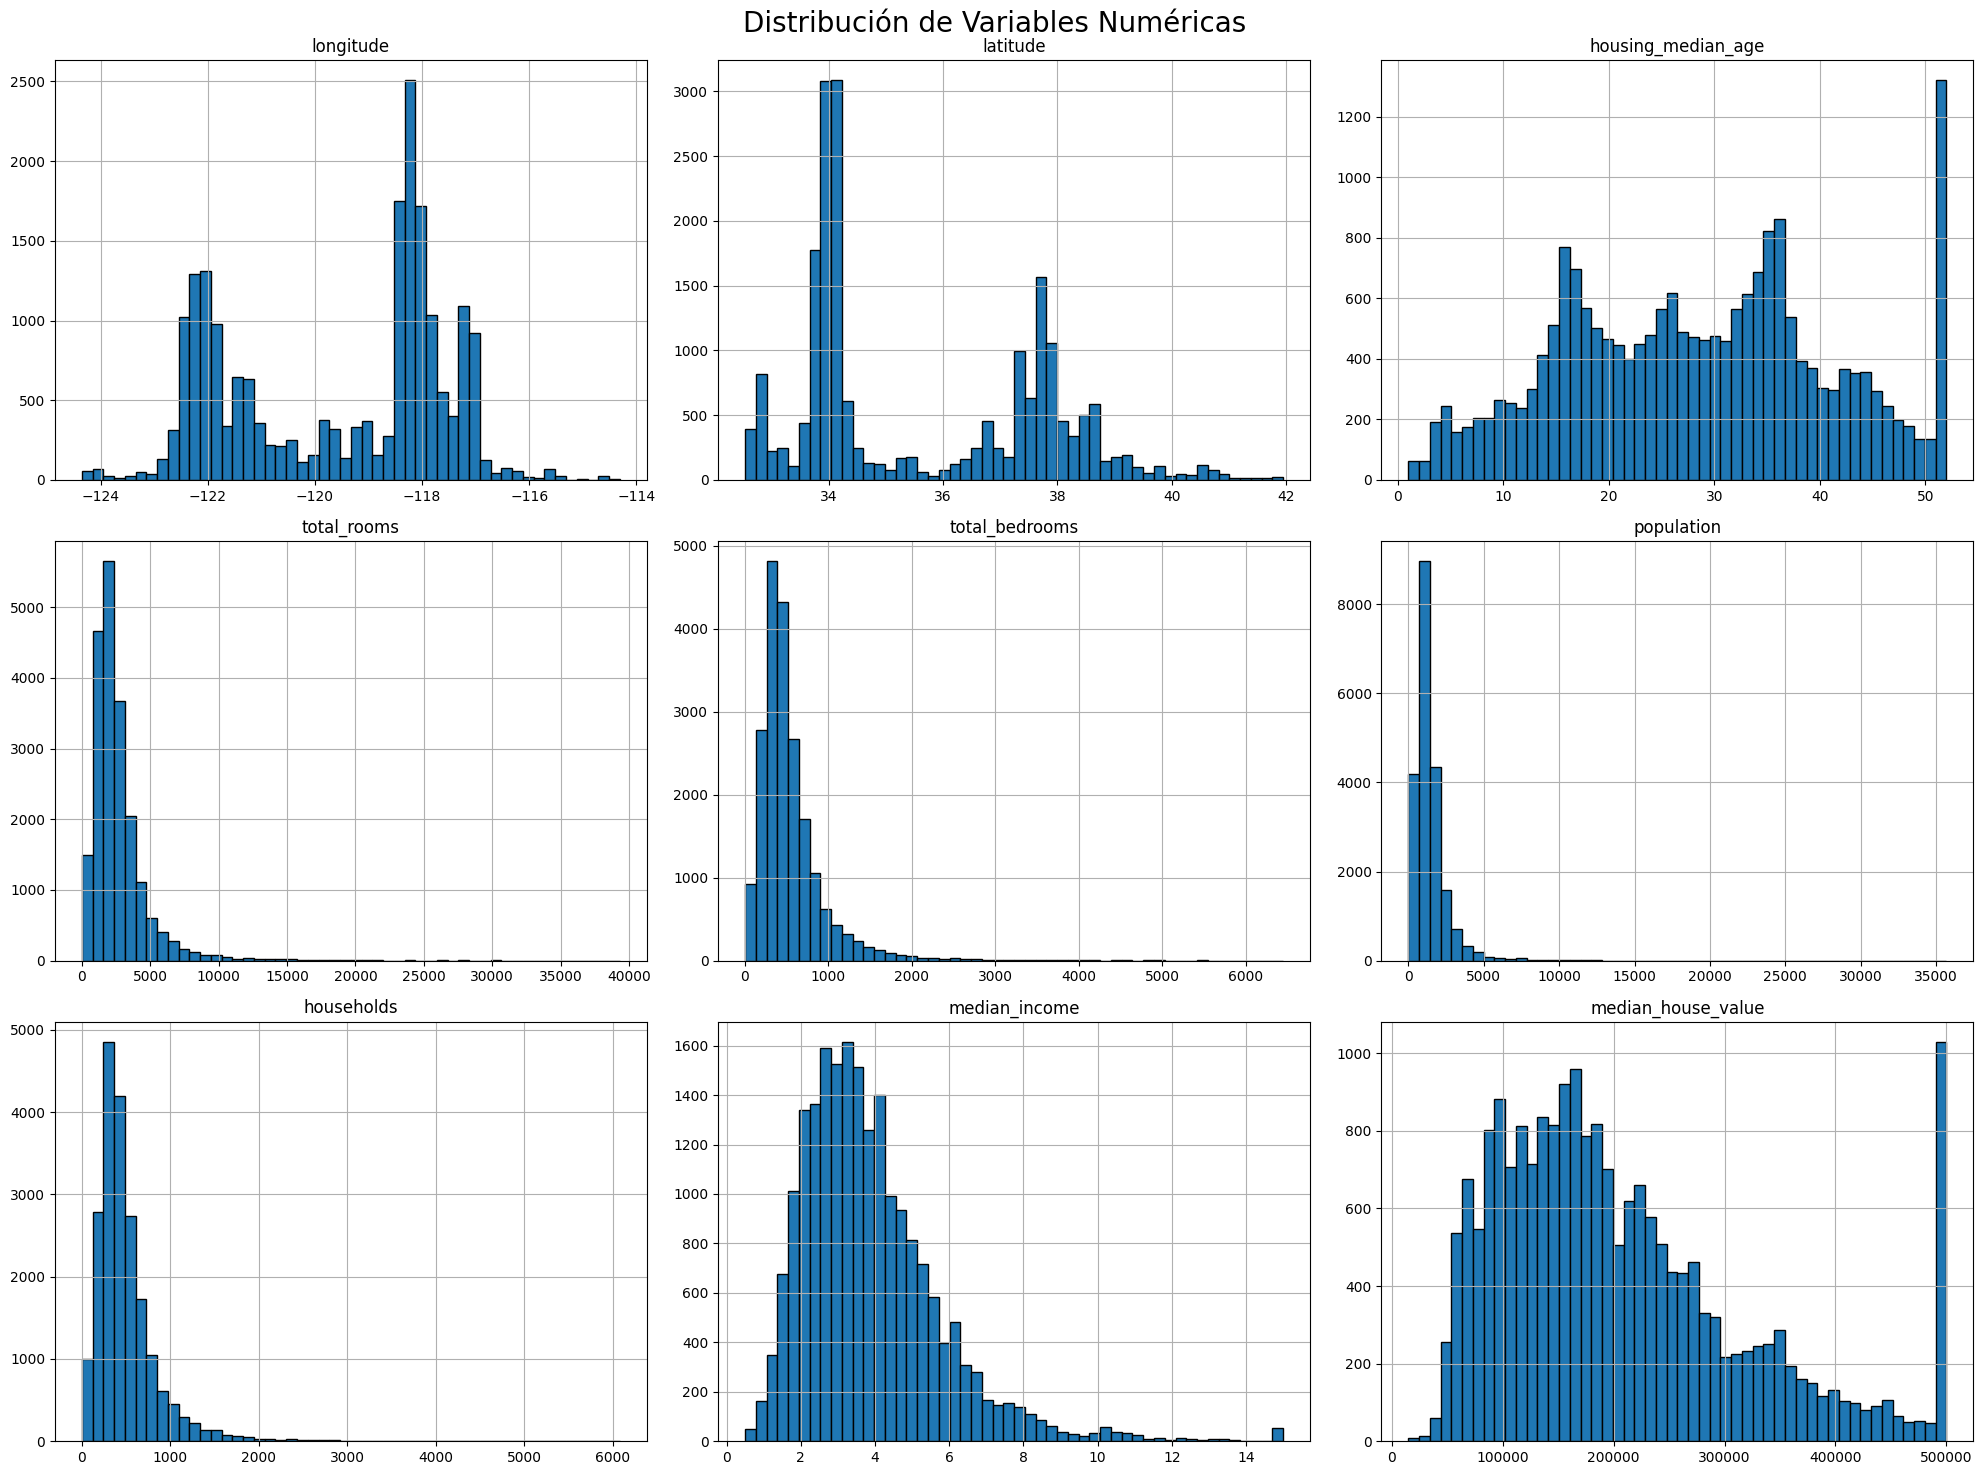

In [12]:
# Seleccionar solo columnas numéricas
num_cols = data.select_dtypes(include='number').columns

# Crear los histogramas
data[num_cols].hist(
    bins=50,
    figsize=(20, 15),
    edgecolor='black'
)

plt.suptitle('Distribución de Variables Numéricas', fontsize=20)
plt.tight_layout()
plt.show()

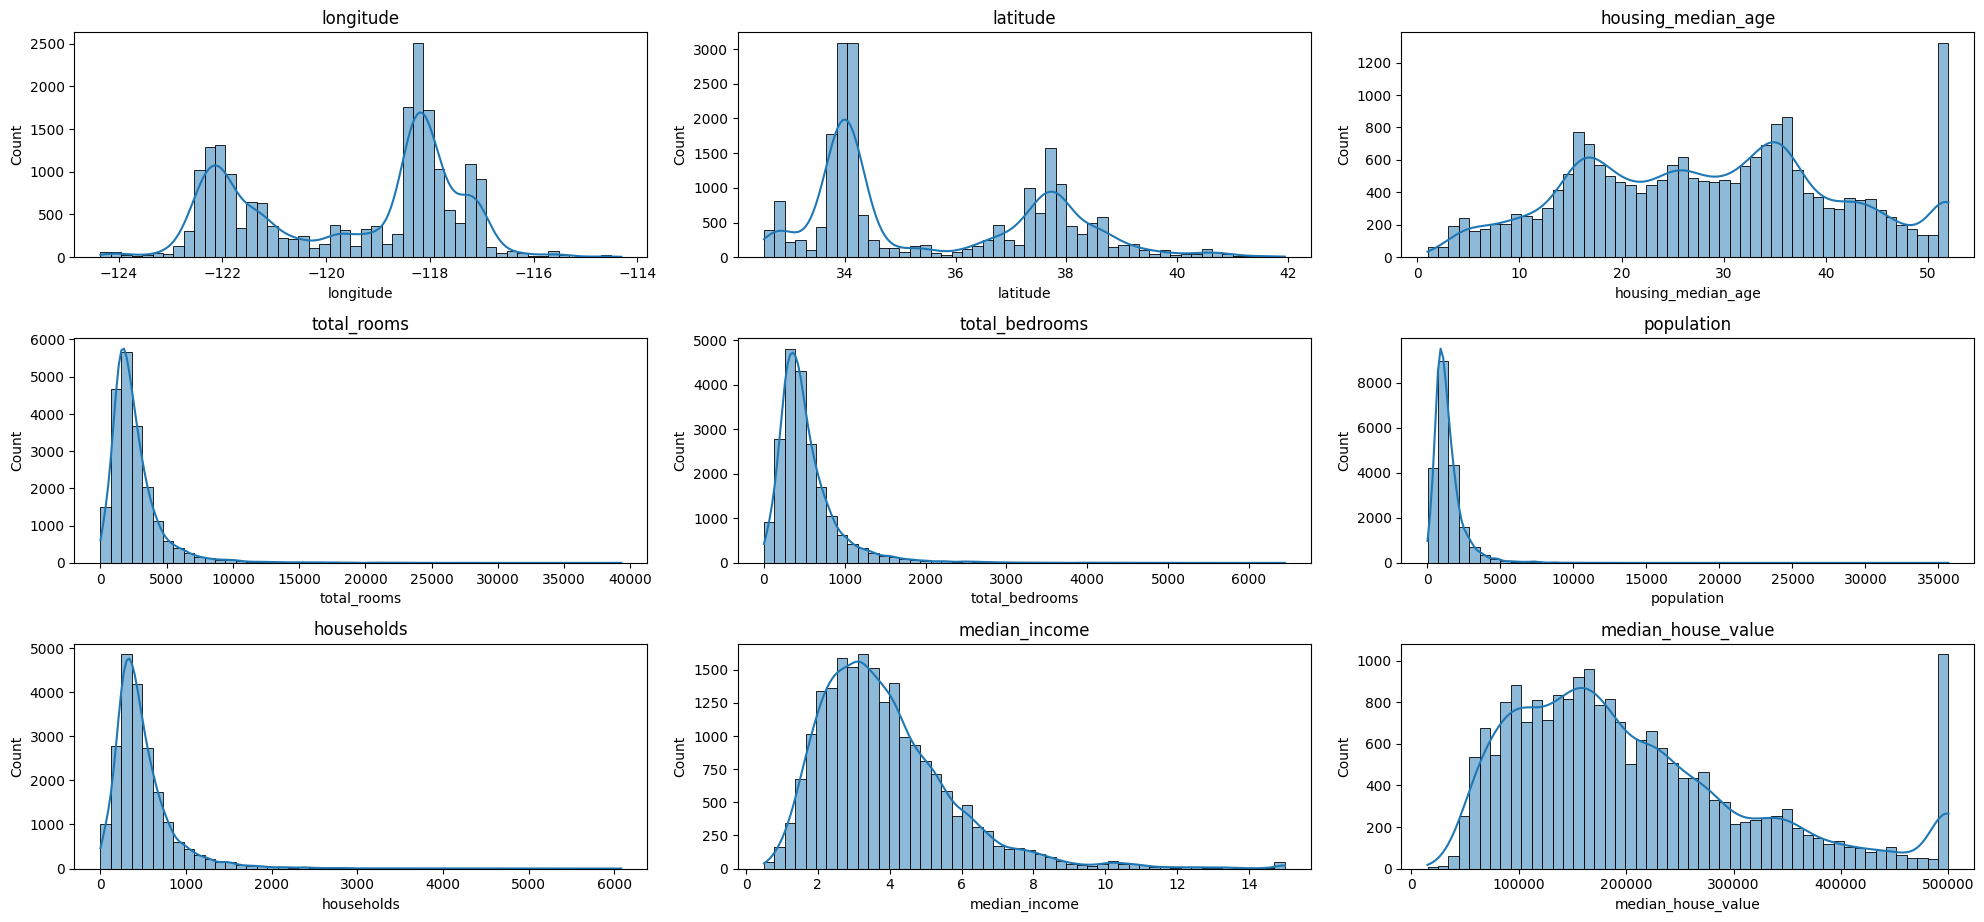

In [13]:
num_cols = data.select_dtypes(include='number').columns

plt.figure(figsize=(20, 15))

for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 3, i)  # ajustá filas/columnas según cantidad
    sns.histplot(
        data[col],
        edgecolor='black',
        bins=50,
        kde=True
    )
    plt.title(col)

plt.tight_layout()
plt.show()

En general, el dataset presenta distribuciones no normales y variables con alta asimetría, lo cual es esperado en datos socioeconómicos reales. No se detectan outliers atribuibles a errores de medición, por lo que se prioriza la transformación de variables sobre la eliminación de observaciones. Estas decisiones permitirán un preprocesamiento más robusto y modelos más estables.

In [32]:
from datetime import datetime

fecha = datetime.now().strftime("%Y-%m-%d")
data.to_csv(f"../data/processed/housing_cleaned_{fecha}.csv", index=False)
